In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
df = pd.read_excel('/content/Dataset.xlsx', sheet_name='Cleaned Dataset')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.strftime('%b')


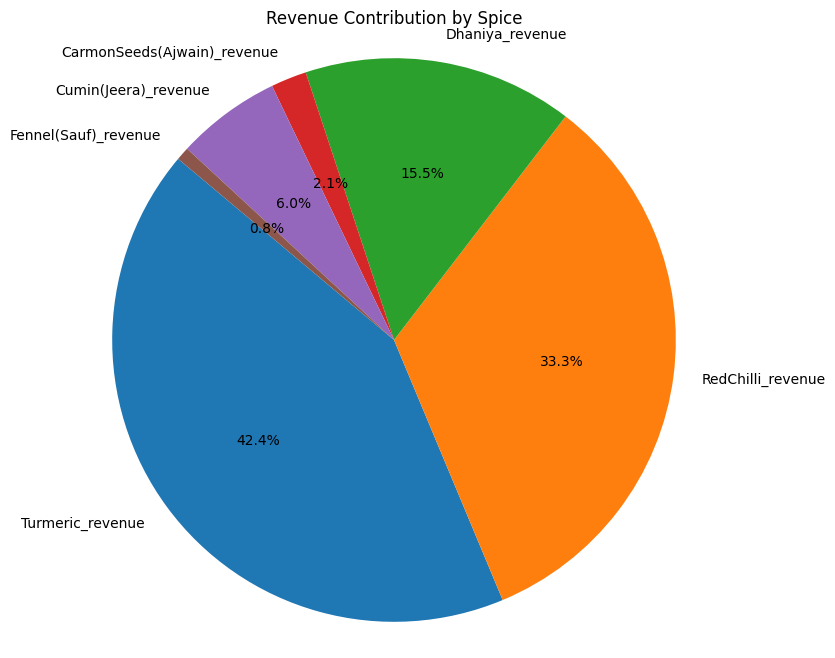

In [ ]:
# Define spice revenue columns based on the sheet
spice_revenue_cols = [
    'Turmeric_revenue',
    'RedChilli_revenue',
    'Dhaniya_revenue',
    'CarmonSeeds(Ajwain)_revenue',
    'Cumin(Jeera)_revenue',
    'Fennel(Sauf)_revenue'
]

# Create pie chart
total_revenue_by_spice = df[spice_revenue_cols].sum()
plt.figure(figsize=(8, 8))
plt.pie(total_revenue_by_spice, labels=total_revenue_by_spice.index, autopct='%1.1f%%', startangle=140)
plt.title('Revenue Contribution by Spice')
plt.axis('equal')
plt.show()


/tmp/ipython-input-1370432305.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_transport.index, y=monthly_transport.values, palette="Oranges_r")


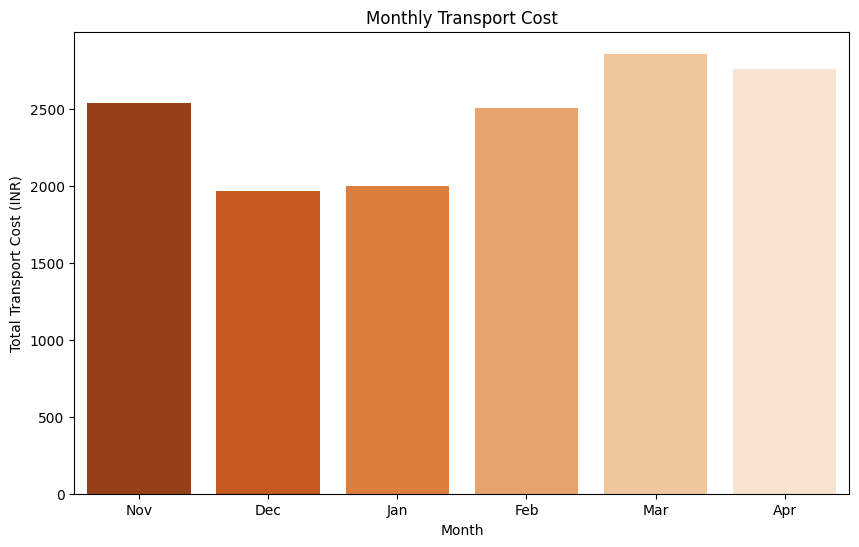

In [ ]:
monthly_transport = df.groupby('Month')['Transport'].sum().reindex(['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_transport.index, y=monthly_transport.values, palette="Oranges_r")
plt.title('Monthly Transport Cost')
plt.xlabel('Month')
plt.ylabel('Total Transport Cost (INR)')
plt.show()


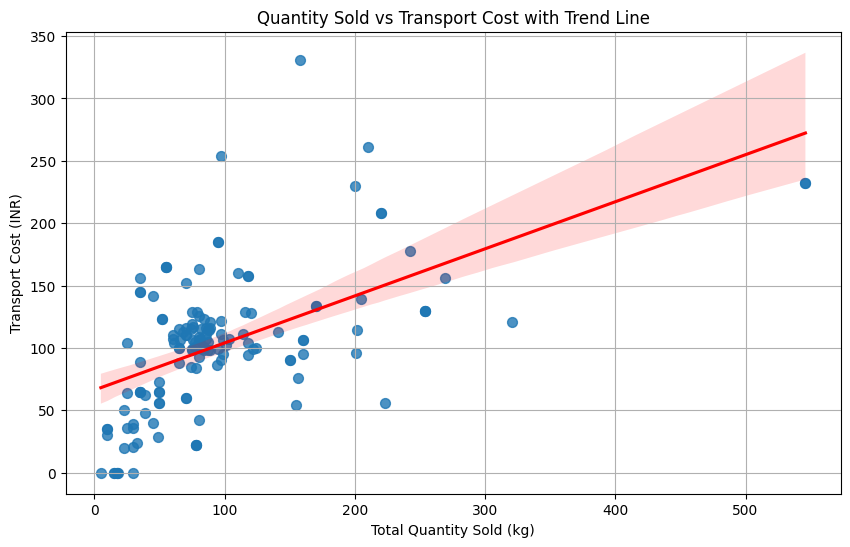

In [ ]:
# First, define the correct spice quantity columns
spice_quantity_cols = [
    'Turmeric_sold(kg)',
    'RedChilli_sold(kg)',
    'Dhaniya_sold(kg)',
    'CarmonSeeds(Ajwain)_sold(kg)',
    'Cumin(Jeera)_sold',
    'Fennel(Sauf)_sold'
]

# Calculate total quantity sold per day
df['Total_Spices_Sold'] = df[spice_quantity_cols].sum(axis=1)

# Scatter plot with trend line
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_Spices_Sold', y='Transport', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Quantity Sold vs Transport Cost with Trend Line')
plt.xlabel('Total Quantity Sold (kg)')
plt.ylabel('Transport Cost (INR)')
plt.grid(True)
plt.show()


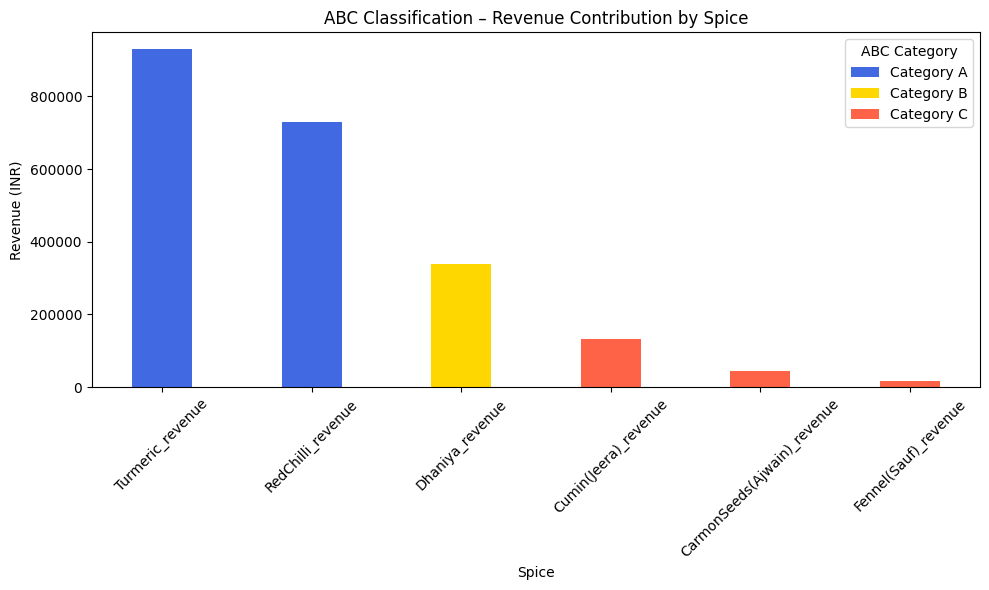

In [ ]:
# Step 1: Total revenue by spice
spice_revenue = df[spice_revenue_cols].sum().sort_values(ascending=False)

# Step 2: Cumulative % and ABC categories
cumulative_percent = spice_revenue.cumsum() / spice_revenue.sum() * 100

abc_category = []
for percent in cumulative_percent:
    if percent <= 80:
        abc_category.append('A')
    elif percent <= 95:
        abc_category.append('B')
    else:
        abc_category.append('C')

# Step 3: Create DataFrame
abc_df = pd.DataFrame({
    'Spice': spice_revenue.index,
    'Revenue': spice_revenue.values,
    'Category': abc_category
})

# Step 4: Use brighter color mapping
category_colors = {'A': 'royalblue', 'B': 'gold', 'C': 'tomato'}
bar_colors = abc_df['Category'].map(category_colors)

# Step 5: Plot bar chart
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(10, 6))
plt.bar(abc_df['Spice'], abc_df['Revenue'], color=bar_colors, width=0.4)

# Legend
legend_elements = [Patch(facecolor=color, label=f'Category {cat}') for cat, color in category_colors.items()]
plt.legend(handles=legend_elements, title='ABC Category')

# Labels and layout
plt.title('ABC Classification – Revenue Contribution by Spice')
plt.xlabel('Spice')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


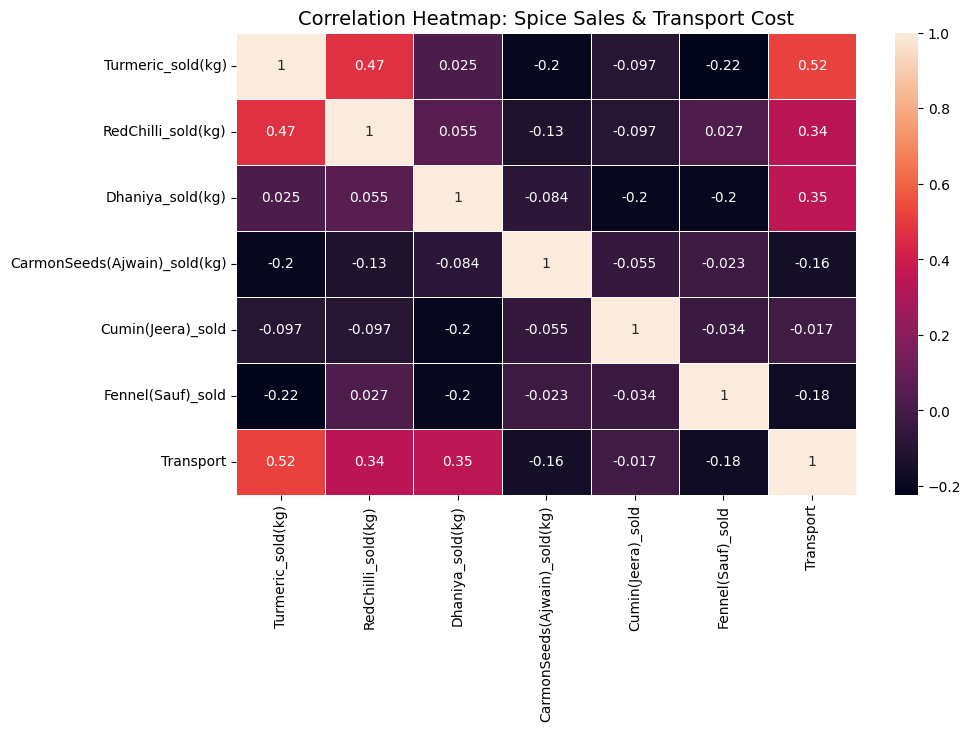

In [ ]:
# Select relevant columns for correlation
correlation_cols = [
    'Turmeric_sold(kg)',
    'RedChilli_sold(kg)',
    'Dhaniya_sold(kg)',
    'CarmonSeeds(Ajwain)_sold(kg)',
    'Cumin(Jeera)_sold',
    'Fennel(Sauf)_sold',
    'Transport'
]

# Compute correlation matrix
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', linewidths=0.5)
plt.title('Correlation Heatmap: Spice Sales & Transport Cost', fontsize=14)
plt.show()



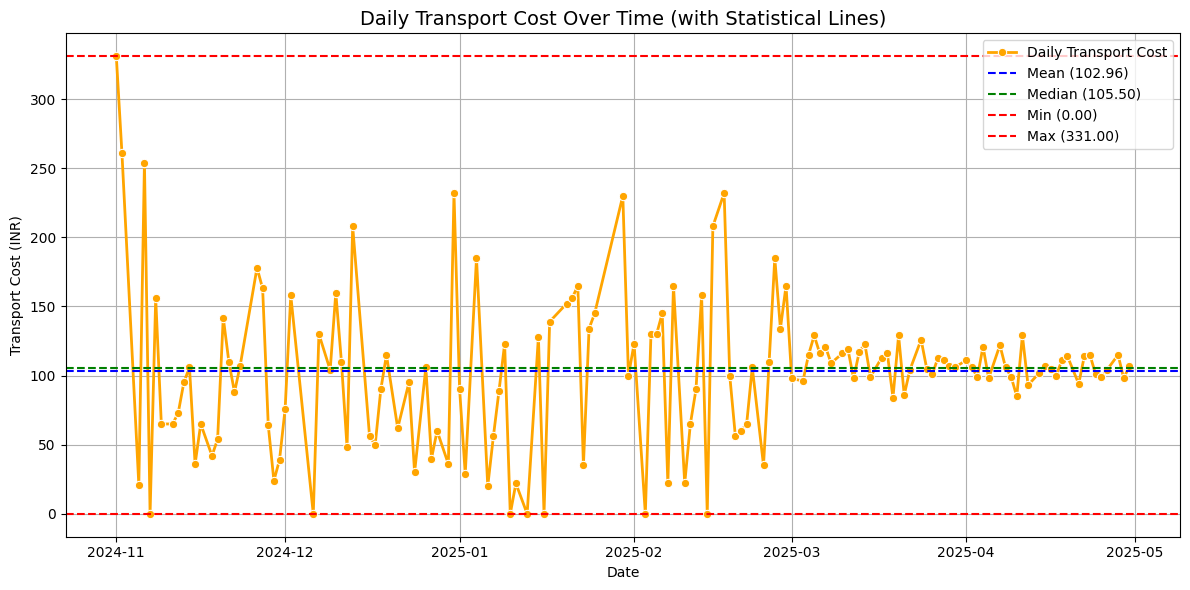

In [ ]:
# Sort by date
df = df.sort_values('Date')

# Calculate key transport statistics
mean_transport = df['Transport'].mean()
median_transport = df['Transport'].median()
min_transport = df['Transport'].min()
max_transport = df['Transport'].max()

# Plot line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Transport', data=df, marker='o', linewidth=2, color='orange', label='Daily Transport Cost')

# Add reference lines
plt.axhline(mean_transport, color='blue', linestyle='--', label=f'Mean ({mean_transport:.2f})')
plt.axhline(median_transport, color='green', linestyle='--', label=f'Median ({median_transport:.2f})')
plt.axhline(min_transport, color='red', linestyle='--', label=f'Min ({min_transport:.2f})')
plt.axhline(max_transport, color='red', linestyle='--', label=f'Max ({max_transport:.2f})')

# Labels and styling
plt.title('Daily Transport Cost Over Time (with Statistical Lines)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Transport Cost (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


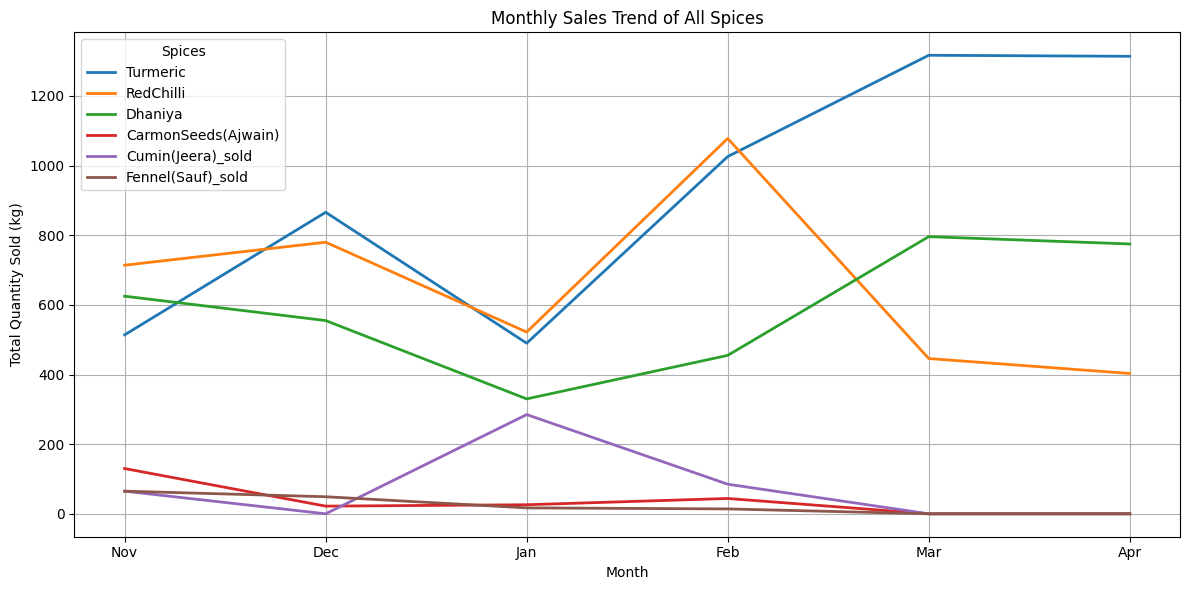

In [ ]:
# Select spice sales columns
spice_sales_cols = [
    'Turmeric_sold(kg)',
    'RedChilli_sold(kg)',
    'Dhaniya_sold(kg)',
    'CarmonSeeds(Ajwain)_sold(kg)',
    'Cumin(Jeera)_sold',
    'Fennel(Sauf)_sold'
]

# Group by month
monthly_sales = df.groupby('Month')[spice_sales_cols].sum().reindex(['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])

# Plot all spice sales
plt.figure(figsize=(12, 6))
for col in spice_sales_cols:
    sns.lineplot(data=monthly_sales, x=monthly_sales.index, y=col, label=col.replace('_sold(kg)', ''), linewidth=2)

plt.title('Monthly Sales Trend of All Spices')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold (kg)')
plt.legend(title='Spices')
plt.grid(True)
plt.tight_layout()
plt.show()
